# RoBERTa Model

### Imports

In [1]:
from transformers import (
    RobertaTokenizer, 
    RobertaForMaskedLM, 
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
    RobertaForSequenceClassification,
    set_seed,
)
from datasets import load_dataset, Value
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

c:\Users\HP\CS175\news-bias-classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Set Seeds

In [2]:
# For consistency in training
SEED = 42
set_seed(SEED)

### Pre-Training on Corpus

In [3]:
# Loading model and tokenizer
roberta_model_mlm = RobertaForMaskedLM.from_pretrained('roberta-base').to('cuda')
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 1162.21it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Load dataset
pretrained_dataset = load_dataset('avanishd/ground-news-2026') 
print(pretrained_dataset)

DatasetDict({
    train: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 4583
    })
    test: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 983
    })
    validation: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 982
    })
})


In [5]:
# Filter out any null summaries
pretrained_dataset = pretrained_dataset.filter(lambda dataset: dataset['summary'] != 'null' and dataset['summary'] is not None and dataset['summary'] != '') 
print(pretrained_dataset)

DatasetDict({
    train: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 4583
    })
    test: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 983
    })
    validation: Dataset({
        features: ['outlet', 'bias', 'headline', 'summary', 'ground_news_interest_url'],
        num_rows: 982
    })
})


In [11]:
# Determines tokenization per data
def tokenize(data):
    return roberta_tokenizer(data['summary'], truncation=True, max_length=512, padding='max_length')

In [7]:
# Example output of tokenizer
print(roberta_tokenizer("The father had two sons, the sons committed sins.", truncation=True, max_length=512, padding='max_length'))

{'input_ids': [0, 133, 1150, 56, 80, 7250, 6, 5, 7250, 2021, 29469, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [8]:
# Tokenizes the descriptions for RoBERTa training and remove unneccessary columns
tokenized_pretrained_dataset = pretrained_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'bias', 'headline', 'ground_news_interest_url'])
print(tokenized_pretrained_dataset) 

Map: 100%|██████████| 982/982 [00:00<00:00, 7929.58 examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 4583
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 983
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 982
    })
})


In [9]:
# Used to mask random tokens
data_collator = DataCollatorForLanguageModeling(tokenizer=roberta_tokenizer, mlm=True, mlm_probability=0.15)

# Parameters used for trainer
training_args = TrainingArguments(
    output_dir='./domain-roberta-mlm',
    save_steps=10000,
    save_total_limit=2,
    logging_steps=500,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    fp16=True
)

trainer = Trainer(model=roberta_model_mlm,
                  args=training_args,
                  data_collator=data_collator,
                  train_dataset=tokenized_pretrained_dataset['train'])

In [10]:
trainer.train() # Training

Step,Training Loss
500,1.529145
1000,1.326188
1500,1.144670


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


TrainOutput(global_step=1719, training_loss=1.3046678650718986, metrics={'train_runtime': 412.6089, 'train_samples_per_second': 33.322, 'train_steps_per_second': 4.166, 'total_flos': 3619636854856704.0, 'train_loss': 1.3046678650718986, 'epoch': 3.0})

In [11]:
# Saving model
roberta_model_mlm.save_pretrained('./domain-roberta-mlm')
roberta_tokenizer.save_pretrained('./domain-roberta-mlm')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


('./domain-roberta-mlm\\tokenizer_config.json',
 './domain-roberta-mlm\\tokenizer.json')

### Data Preprocessing for Classification

In [7]:
# Load dataset
classifier_dataset = load_dataset('avanishd/ground-news-2026')

In [8]:
# Filter out any null summaries
classifier_dataset = classifier_dataset.filter(lambda dataset: dataset['summary'] != 'null' and dataset['summary'] is not None and dataset['summary'] != '')

### Train for Classification (With Base Model)

In [9]:
# Load base model
roberta_model_classifier_with_base = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=7).to('cuda')
# IMPORTANT, reassign roberta_tokenizer so tokenize function uses the correct tokenizer
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 973.42it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [12]:
# Tokenizes the descriptions for RoBERTa training
tokenized_classifier_dataset_base = classifier_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'headline', 'ground_news_interest_url'])

Map: 100%|██████████| 983/983 [00:00<00:00, 6866.37 examples/s]


In [13]:
# Rename column from bias to labels
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.rename_column('bias', 'labels')

# Map label strings to integers
label_map = {"Far Left": 0, "Left": 1, "Lean Left": 2, "Center": 3, "Lean Right": 4, "Right": 5, "Far Right": 6}
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.map(lambda dataset: {'labels': int(label_map[dataset['labels']])})
tokenized_classifier_dataset_base = tokenized_classifier_dataset_base.cast_column('labels', Value('int32'))

print(tokenized_classifier_dataset_base)
print(tokenized_classifier_dataset_base['train']['labels'])

Casting the dataset: 100%|██████████| 983/983 [00:00<00:00, 62303.57 examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 4583
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 983
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 982
    })
})
Column([3, 5, 2, 5, 3])


In [17]:
# Parameters used for trainer
training_args_base = TrainingArguments(
    output_dir='./domain-roberta-classifier-base',
    save_strategy='epoch',
    eval_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=500,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    fp16=True
)

trainer_base = Trainer(model=roberta_model_classifier_with_base,
                  args=training_args_base,
                  train_dataset=tokenized_classifier_dataset_base['train'],
                  eval_dataset=tokenized_classifier_dataset_base['validation'])

In [18]:
trainer_base.train() # Training

Epoch,Training Loss,Validation Loss
1,No log,1.368542
2,1.333624,1.248088
3,1.333624,1.176334
4,1.038919,1.193908
5,1.038919,1.218858


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.54it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=1435, training_loss=1.060088558396396, metrics={'train_runtime': 453.8223, 'train_samples_per_second': 50.493, 'train_steps_per_second': 3.162, 'total_flos': 6029460501888000.0, 'train_loss': 1.060088558396396, 'epoch': 5.0})

In [19]:
# Saving model
roberta_model_classifier_with_base.save_pretrained('./domain-roberta-classifier-base')
roberta_tokenizer.save_pretrained('./domain-roberta-classifier-base')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.11it/s]


('./domain-roberta-classifier-base\\tokenizer_config.json',
 './domain-roberta-classifier-base\\tokenizer.json')

### Evaluation

In [5]:
# List of label names
label_names = ["Left", "Lean Left", "Center", "Right", "Far Right"]

# Metric function, that will produce all needed metrics
def metric_runner(model: Trainer, data):
    predictions = model.predict(data['test'])
    preds = np.argmax(predictions.predictions, axis=-1)
    true_labels = predictions.label_ids

    print(f"Mean Absolule Error: {mean_absolute_error(true_labels, preds)}")
    print()
    print(classification_report(true_labels, preds, target_names=label_names))

    cm = confusion_matrix(true_labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot()
    plt.show()

Mean Absolule Error: 0.9582909460834181

              precision    recall  f1-score   support

        Left       0.38      0.20      0.26        51
   Lean Left       0.45      0.46      0.46       252
      Center       0.60      0.59      0.60       371
       Right       0.50      0.55      0.53       283
   Far Right       0.59      0.65      0.62        26

    accuracy                           0.53       983
   macro avg       0.51      0.49      0.49       983
weighted avg       0.52      0.53      0.52       983



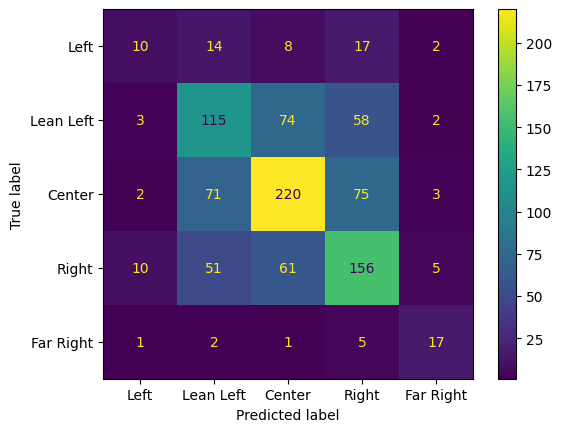

In [21]:
metric_runner(trainer_base, tokenized_classifier_dataset_base) # Get metrics and evaluation

### Train for Classification (With Pretrained Model)

In [14]:
# Load base model
roberta_model_classifier_with_pretrained = RobertaForSequenceClassification.from_pretrained('./domain-roberta-mlm', num_labels=7).to('cuda')
# IMPORTANT, reassign roberta_tokenizer so tokenize function uses the correct tokenizer
roberta_tokenizer = RobertaTokenizer.from_pretrained('./domain-roberta-mlm')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 971.09it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: ./domain-roberta-mlm
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
# Tokenizes the descriptions for RoBERTa training
tokenized_classifier_dataset_pretrained = classifier_dataset.map(tokenize, batched=True, remove_columns=['summary', 'outlet', 'headline', 'ground_news_interest_url'])

Map: 100%|██████████| 982/982 [00:00<00:00, 7479.79 examples/s]


In [16]:
# Rename column from bias to labels
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.rename_column('bias', 'labels')

# Map label strings to integers
label_map = {"Far Left": 0, "Left": 1, "Lean Left": 2, "Center": 3, "Lean Right": 4, "Right": 5, "Far Right": 6}
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.map(lambda dataset: {'labels': int(label_map[dataset['labels']])})
tokenized_classifier_dataset_pretrained = tokenized_classifier_dataset_pretrained.cast_column('labels', Value('int32'))

print(tokenized_classifier_dataset_pretrained)
print(tokenized_classifier_dataset_pretrained['train']['labels'])

Casting the dataset: 100%|██████████| 982/982 [00:00<00:00, 55871.71 examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 4583
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 983
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 982
    })
})
Column([3, 5, 2, 5, 3])


In [11]:
# Parameters used for trainer
training_args_pretrained = TrainingArguments(
    output_dir='./domain-roberta-classifier-pretrained',
    save_strategy='epoch',
    eval_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=500,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    fp16=True
)

trainer_pretrained = Trainer(model=roberta_model_classifier_with_pretrained,
                  args=training_args_pretrained,
                  train_dataset=tokenized_classifier_dataset_pretrained['train'],
                  eval_dataset=tokenized_classifier_dataset_pretrained['validation'])

In [12]:
trainer_pretrained.train() # Training

Epoch,Training Loss,Validation Loss
1,No log,1.378112
2,1.352392,1.264336
3,1.352392,1.195098
4,1.085509,1.203110
5,1.085509,1.204917


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.45it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=1435, training_loss=1.1048401304238349, metrics={'train_runtime': 454.2014, 'train_samples_per_second': 50.451, 'train_steps_per_second': 3.159, 'total_flos': 6029460501888000.0, 'train_loss': 1.1048401304238349, 'epoch': 5.0})

In [13]:
# Saving model
roberta_model_classifier_with_pretrained.save_pretrained('./domain-roberta-classifier-pretrained')
roberta_tokenizer.save_pretrained('./domain-roberta-classifier-pretrained')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]


('./domain-roberta-classifier-pretrained\\tokenizer_config.json',
 './domain-roberta-classifier-pretrained\\tokenizer.json')

### Evaluation

Mean Absolule Error: 1.0356052899287895

              precision    recall  f1-score   support

        Left       0.32      0.25      0.28        51
   Lean Left       0.44      0.33      0.38       252
      Center       0.58      0.56      0.57       371
       Right       0.48      0.63      0.54       283
   Far Right       0.56      0.38      0.45        26

    accuracy                           0.50       983
   macro avg       0.47      0.43      0.44       983
weighted avg       0.50      0.50      0.49       983



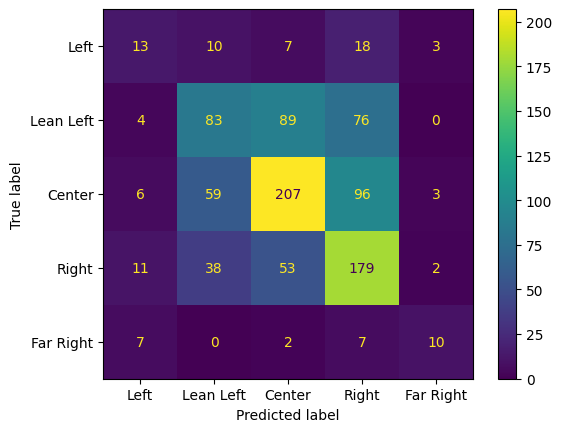

In [14]:
metric_runner(trainer_pretrained, tokenized_classifier_dataset_pretrained) # Get metrics and evaluation

### Check Significance of Results with Bootstrapping

In [38]:
def bootstrap_f1(y_true, y_pred_a, y_pred_b, n_boot=10000):
    rng = np.random.RandomState(42)
    n = len(y_true)
    boot_diffs = []

    a_score = f1_score(y_true, y_pred_a, average='macro')
    b_score = f1_score(y_true, y_pred_b, average='macro')
    score_diff = a_score - b_score

    for _ in range(n_boot):
        idex_list = rng.randint(0, n, size=n)

        f1_a = f1_score(y_true[idex_list], y_pred_a[idex_list], average="macro")
        f1_b = f1_score(y_true[idex_list], y_pred_b[idex_list], average="macro")

        boot_diffs.append(f1_a - f1_b)

    boot_diffs = np.array(boot_diffs)
    p_value = np.mean(boot_diffs <= 0)

    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    
    print("F1 Score A: ", a_score)
    print("F1 Score B: ", b_score)
    print("F1 Score Difference: ", score_diff)
    print("CI Lower: ", ci_lower)
    print("CI Upper: ", ci_upper)
    print("P Value: ", p_value)
    print("Significant: ", 0.0 < ci_lower or ci_upper < 0.0)

In [22]:
base_trainer = Trainer(RobertaForSequenceClassification.from_pretrained('./domain-roberta-classifier-base'))
pretrained_trainer = Trainer(RobertaForSequenceClassification.from_pretrained('./domain-roberta-classifier-pretrained'))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1124.25it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


In [33]:
base_predictions = base_trainer.predict(tokenized_classifier_dataset_base['test'])
base_preds = np.argmax(base_predictions.predictions, axis=-1)
true_labels = base_predictions.label_ids

pretrained_predictions = pretrained_trainer.predict(tokenized_classifier_dataset_pretrained['test'])
pretrained_preds = np.argmax(pretrained_predictions.predictions, axis=-1)

In [39]:
bootstrap_f1(true_labels, base_preds, pretrained_preds)

F1 Score A:  0.49212836649811437
F1 Score B:  0.44477366801731255
F1 Score Difference:  0.047354698480801816
CI Lower:  0.0009013670487865223
CI Upper:  0.09597667228660817
P Value:  0.0226
Significant:  True
